## Additional notebook


Here is the link to download the dataset used in this notebook: [Dataset](https://drive.google.com/file/d/1NRcWl1DdgpDSBV5S7idYyM-t0lkBH8z6/view?usp=drive_link).

NLTK

In [2]:
import pandas as pd

# Read the CSV file into a DataFrame
df2 = pd.read_csv("/content/df2.csv")


In [3]:
df2.head()

,input,output,input_length,output_length,input_word_count,output_word_count,input_unique_words,output_unique_words,input_empty,output_empty,question_tokens_spacy,answer_tokens_spacy,question_tokens_spacy_lemma,answer_tokens_spacy_lemma,question_tokens_spacy2,answer_tokens_spacy2
0,What is the relationship between very low Mg2+...,Very low Mg2+ levels correspond to low PTH lev...,83,91,17,18,14,13,False,False,"['relationship', 'low', 'levels', 'pth', 'leve...","['low', 'levels', 'correspond', 'low', 'pth', ...","['relationship', 'low', 'level', 'pth', 'level...","['low', 'level', 'correspond', 'low', 'pth', '...","['relationship', 'low', 'level', 'pth', 'level...","['low', 'level', 'correspond', 'low', 'pth', '..."
1,What leads to genitourinary syndrome of menopa...,Low estradiol production leads to genitourinar...,71,91,12,14,12,14,False,False,"['leads', 'genitourinary', 'syndrome', 'menopa...","['low', 'estradiol', 'production', 'leads', 'g...","['lead', 'genitourinary', 'syndrome', 'menopau...","['low', 'estradiol', 'production', 'lead', 'ge...","['lead', 'genitourinary', 'syndrome', 'menopau...","['low', 'estradiol', 'production', 'lead', 'ge..."
2,What does low REM sleep latency and experienci...,Low REM sleep latency and experiencing halluci...,88,90,12,11,12,11,False,False,"['low', 'rem', 'sleep', 'latency', 'experienci...","['low', 'rem', 'sleep', 'latency', 'experienci...","['low', 'rem', 'sleep', 'latency', 'experience...","['low', 'rem', 'sleep', 'latency', 'experience...","['low', 'rem', 'sleep', 'latency', 'experience...","['low', 'rem', 'sleep', 'latency', 'experience..."
3,What are some possible causes of low PTH and h...,"PTH-independent hypercalcemia, which can be ca...",65,111,13,18,13,16,False,False,"['possible', 'causes', 'low', 'pth', 'high', '...","['pth', 'independent', 'hypercalcemia', 'cause...","['possible', 'cause', 'low', 'pth', 'high', 'c...","['pth', 'independent', 'hypercalcemia', 'cause...","['possible', 'cause', 'low', 'pth', 'high', 'c...","['hypercalcemia', 'cause', 'cancer', 'granulom..."
4,How does the level of anti-müllerian hormone r...,The level of anti-müllerian hormone is directl...,71,125,12,21,12,16,False,False,"['level', 'anti', 'müllerian', 'hormone', 'rel...","['level', 'anti', 'müllerian', 'hormone', 'dir...","['level', 'anti', 'müllerian', 'hormone', 'rel...","['level', 'anti', 'müllerian', 'hormone', 'dir...","['level', 'hormone', 'relate', 'ovarian', 'res...","['level', 'hormone', 'directly', 'related', 'o..."


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.



Top 20 Most Common Words in Inputs (Excluding Stopwords):
[('type', 3069), ('associated', 2738), ('cause', 1974), ('condition', 1781), ('treatment', 1644), ('patients', 1642), ('recommended', 1507), ('syndrome', 1484), ('symptoms', 1420), ('name', 1404), ('commonly', 1393), ('patient', 1370), ('common', 1366), ('potential', 1351), ('effect', 1339), ('disease', 1328), ('cells', 1046), ('diagnosis', 923), ('risk', 916), ('cell', 845)]

Top 20 Most Common Words in Outputs (Excluding Stopwords):
[('treatment', 8559), ('blood', 8505), ('symptoms', 8371), ('cause', 7606), ('cells', 5912), ('condition', 5763), ('patients', 5016), ('disease', 4978), ('type', 4741), ('lead', 4257), ('risk', 3953), ('infection', 3743), ('associated', 3652), ('body', 3591), ('including', 3575), ('levels', 3530), ('pain', 3315), ('cancer', 3290), ('syndrome', 3197), ('caused', 3183)]


<ipython-input-9-a4e0ae50311d>:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=input_top_df2, x='Frequency', y='Word', palette='Blues_d')


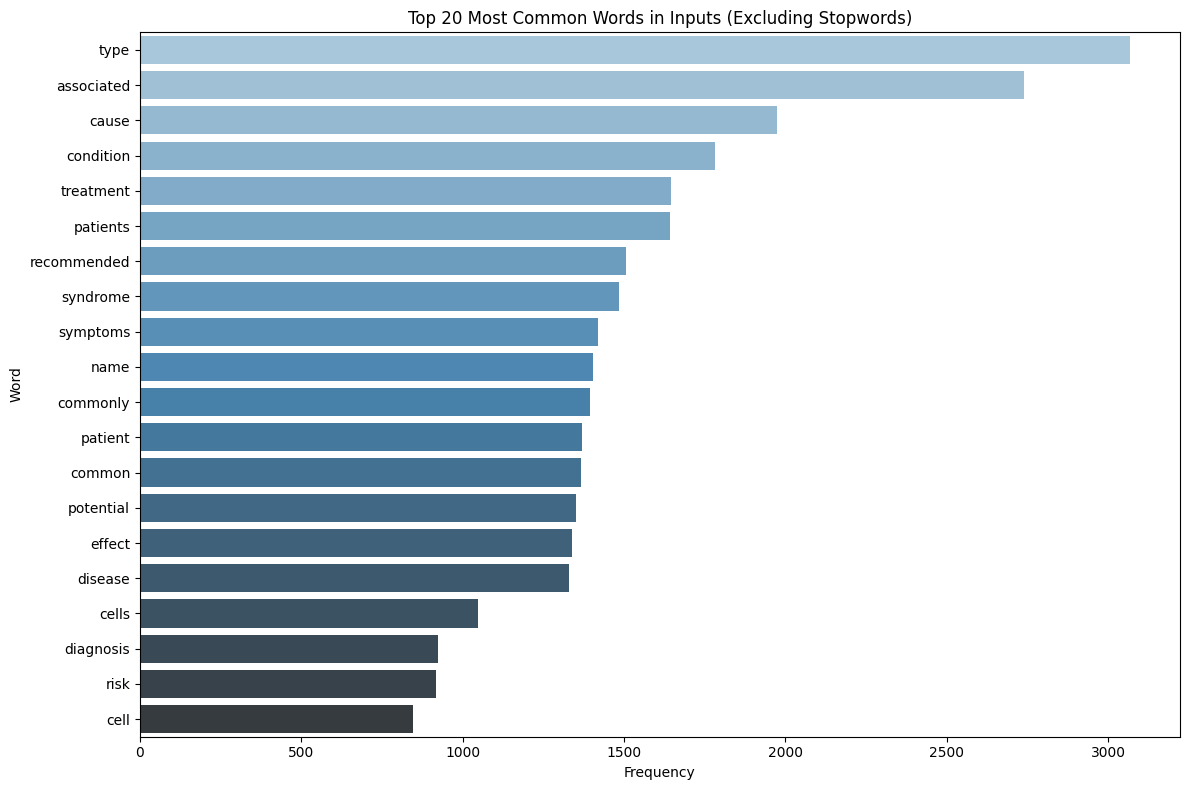

<ipython-input-9-a4e0ae50311d>:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=output_top_df2, x='Frequency', y='Word', palette='Reds_d')


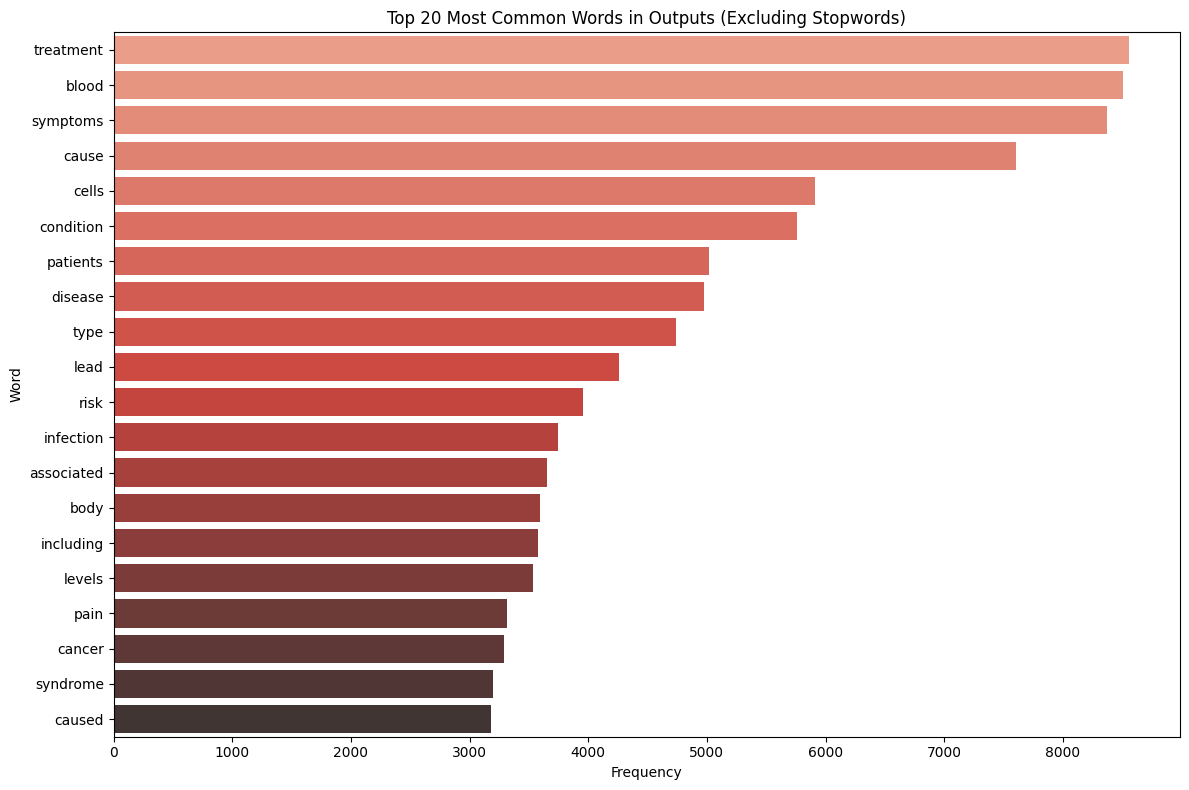

In [9]:
from nltk.corpus import stopwords
import pandas as pd
import nltk
from nltk.tokenize import word_tokenize
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import re
# Download NLTK data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

# Define stopwords
nltk_stop_words = set(stopwords.words('english'))
custom_stop_words = ['may', 'important', 'also', 'used', 'include', 'typically']
stop_words = nltk_stop_words.union(custom_stop_words)


def preprocess(text):
    # Convert to string and remove apostrophes
    text = str(text).replace("'", "")
    # Tokenize and lowercase
    tokens = word_tokenize(text.lower())
    # Remove non-alphanumeric characters from tokens
    tokens = [re.sub(r"[^\w\s]", "", word) for word in tokens]
    # Filter out non-alphabetic tokens
    tokens = [word for word in tokens if word.isalpha()]
    # Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]
    return tokens


# Apply preprocessing
df2['input_tokens'] = df2['input'].apply(preprocess)
df2['output_tokens'] = df2['output'].apply(preprocess)

# Combine all tokens from inputs and outputs
all_input_tokens = [word for tokens in df2['input_tokens'] for word in tokens]
all_output_tokens = [word for tokens in df2['output_tokens'] for word in tokens]

# Count frequency
input_freq = Counter(all_input_tokens)
output_freq = Counter(all_output_tokens)

# Get top 20
top_input = input_freq.most_common(20)
top_output = output_freq.most_common(20)

print("\nTop 20 Most Common Words in Inputs (Excluding Stopwords):")
print(top_input)

print("\nTop 20 Most Common Words in Outputs (Excluding Stopwords):")
print(top_output)

# Visualization of Top Words

# Inputs
input_top_df2 = pd.DataFrame(top_input, columns=['Word', 'Frequency'])
plt.figure(figsize=(12, 8))
sns.barplot(data=input_top_df2, x='Frequency', y='Word', palette='Blues_d')
plt.title('Top 20 Most Common Words in Inputs (Excluding Stopwords)')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.tight_layout()
plt.show()

# Outputs
output_top_df2 = pd.DataFrame(top_output, columns=['Word', 'Frequency'])
plt.figure(figsize=(12, 8))
sns.barplot(data=output_top_df2, x='Frequency', y='Word', palette='Reds_d')
plt.title('Top 20 Most Common Words in Outputs (Excluding Stopwords)')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.tight_layout()
plt.show()

Using SpaCy (en_core_web_sm)

In [10]:
import spacy
from gensim.models import Word2Vec
import pandas as pd

# English model
nlp = spacy.load("en_core_web_sm")

# Preprocess text using spaCy
def preprocess_with_spacy(text):
    doc = nlp(str(text).lower())  # Process the text and lowercase it
    tokens = [
        token.text for token in doc
        if token.is_alpha and not token.is_stop  # Keep only alphabetic tokens and exclude stopwords
    ]
    return tokens


df2['question_tokens_spacy'] = df2['input'].apply(preprocess_with_spacy)
df2['answer_tokens_spacy'] = df2['output'].apply(preprocess_with_spacy)

# Combine token input and output for Word2Vec training
all_sentences = df2['question_tokens_spacy'].tolist() + df2['answer_tokens_spacy'].tolist()

# Train Word2Vec model
word2vec_model = Word2Vec(
    sentences=all_sentences,  # Tokenized sentences
    vector_size=100,          # Size of word embeddings
    window=5,                 # Context window size
    min_count=2,              # Minimum frequency of words
    workers=4,                # Number of CPU threads
    sg=0                      # Use CBOW (sg=0) or Skip-Gram (sg=1)
)

word2vec_model.save("word2vec_model_medicine_spacy.bin")

# Vocabulary size
print("Vocabulary size:", len(word2vec_model.wv))

# Test the model with a word
example_word = 'disease'
if example_word in word2vec_model.wv:
    print("Most similar words to '{}':".format(example_word))
    print(word2vec_model.wv.most_similar(example_word))
else:
    print("Word '{}' not in vocabulary.".format(example_word))

Vocabulary size: 18191
Most similar words to 'disease':
[('diseases', 0.6306185722351074), ('ophthalmopathy', 0.5326873064041138), ('dementia', 0.5229848027229309), ('nephropathy', 0.5216213464736938), ('colitis', 0.5120510458946228), ('sarcoidosis', 0.511228621006012), ('leukoencephalopathy', 0.48778200149536133), ('ibd', 0.48747995495796204), ('transplant', 0.4855319559574127), ('hippel', 0.4829104244709015)]


In [11]:
# Count unique words
unique_input_words = set([word for tokens in df2['question_tokens_spacy'] for word in tokens])
unique_output_words = set([word for tokens in df2['answer_tokens_spacy'] for word in tokens])

print(f"Number of unique words in inputs (spaCy): {len(unique_input_words)}")
print(f"Number of unique words in outputs (spaCy): {len(unique_output_words)}")


Number of unique words in inputs (spaCy): 14763
Number of unique words in outputs (spaCy): 21498


- Including Lemmatization

In [12]:
# Preprocess text with lemmatization
def preprocess_with_spacy_lemmatization(text):
    doc = nlp(str(text).lower())  # Process the text and lowercase it
    tokens = [
        token.lemma_ for token in doc
        if token.is_alpha and not token.is_stop  # Keep only alphabetic tokens and exclude stopwords
    ]
    return tokens


# Apply the lemmatization-based preprocessing
df2['question_tokens_spacy_lemma'] = df2['input'].apply(preprocess_with_spacy_lemmatization)
df2['answer_tokens_spacy_lemma'] = df2['output'].apply(preprocess_with_spacy_lemmatization)

# Count unique words after lemmatization
unique_input_words_lemma = set([word for tokens in df2['question_tokens_spacy_lemma'] for word in tokens])
unique_output_words_lemma = set([word for tokens in df2['answer_tokens_spacy_lemma'] for word in tokens])

print(f"Number of unique words in inputs after lemmatization: {len(unique_input_words_lemma)}")
print(f"Number of unique words in outputs after lemmatization: {len(unique_output_words_lemma)}")

Number of unique words in inputs after lemmatization: 12702
Number of unique words in outputs after lemmatization: 18116


In [13]:
# Combine lemmatized token input and output for Word2Vec training
all_sentences_lemma = df2['question_tokens_spacy_lemma'].tolist() + df2['answer_tokens_spacy_lemma'].tolist()

# Train Word2Vec model on lemmatized tokens
word2vec_model_lemma = Word2Vec(
    sentences=all_sentences_lemma,  # Tokenized sentences (lemmatized)
    vector_size=100,                # Size of word embeddings
    window=5,                       # Context window size
    min_count=2,                    # Minimum frequency of words
    workers=4,                      # Number of CPU threads
    sg=0                            # Use CBOW (sg=0) or Skip-Gram (sg=1)
)

# Save the model
word2vec_model_lemma.save("word2vec_model_medicine_spacy_lemma.bin")

# Vocabulary size
print("Vocabulary size after lemmatization:", len(word2vec_model_lemma.wv))

# Test the model with a word
example_word = 'disease'
if example_word in word2vec_model_lemma.wv:
    print("Most similar words to '{}' (lemmatized):".format(example_word))
    print(word2vec_model_lemma.wv.most_similar(example_word))
else:
    print("Word '{}' not in vocabulary (lemmatized).".format(example_word))

Vocabulary size after lemmatization: 15343
Most similar words to 'disease' (lemmatized):
[('nephropathy', 0.5269078016281128), ('polyendocrine', 0.49683624505996704), ('von', 0.4903433620929718), ('ophthalmopathy', 0.4889749586582184), ('alm', 0.4850493371486664), ('cirrhosis', 0.480036199092865), ('ibd', 0.47852447628974915), ('hippel', 0.47421377897262573), ('dementia', 0.4721128046512604), ('sarcoidosis', 0.4641101658344269)]
